In [37]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()
    plt.tight_layout()
    plt.show()

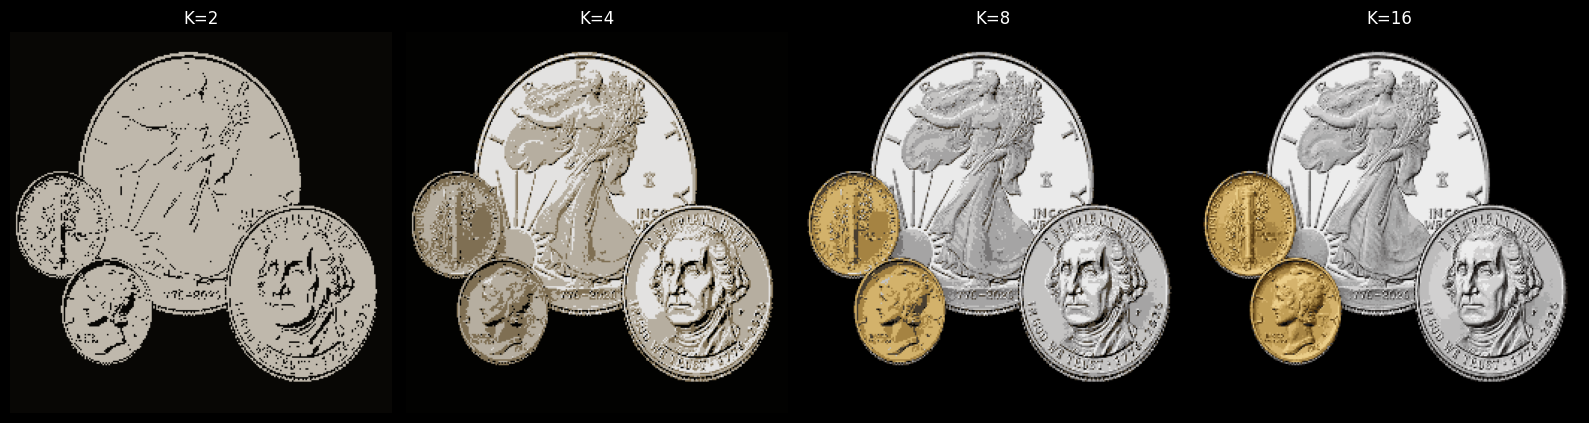

In [38]:
#1, 2 K-Means colour segmentation
img = LoadImage('4_coins.jpg')

h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = [2,4,8,16]
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)

clustered_img = []

for k in k_means:
    compactness, labels, centers = cv2.kmeans(
        img,
        k,
        None,
        criteria,
        1,
        cv2.KMEANS_PP_CENTERS
    )
    clustered = centers[labels.flatten()]
    clustered = clustered.reshape(h,w,3).astype(np.uint8)
    clustered_img.append(clustered)

#matplotlib uses rgb, so converted to rgb for display
clustered_RGB = [cv2.cvtColor(k, cv2.COLOR_BGR2RGB) for k in clustered_img]

titles = [f"K={k}" for k in k_means]

plot_images_grid(clustered_RGB, titles, cols=4, figsize=(16,6))



We can see the

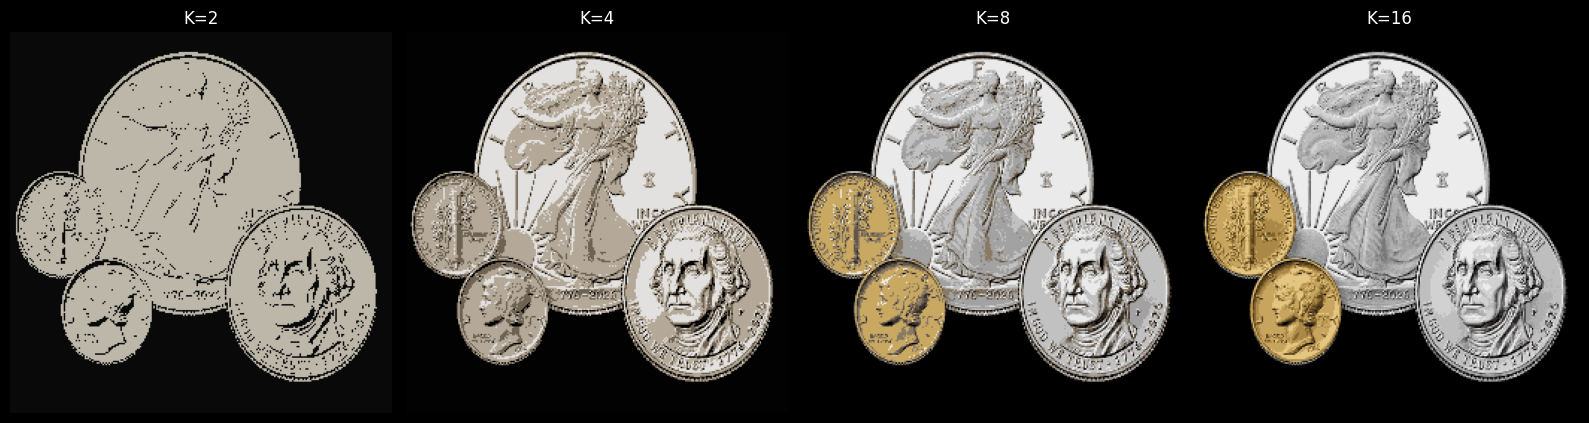

In [39]:
#1 K-Means colour segmentation
img = LoadImage('4_coins.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = [2,4,8,16]
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)

clustered_img = []


for k in k_means:
    compactness, labels, centers = cv2.kmeans(
        img,
        k,
        None,
        criteria,
        1,
        cv2.KMEANS_PP_CENTERS
    )
    clustered = centers[labels.flatten()]
    clustered = clustered.reshape(h,w,3).astype(np.uint8)
    clustered_img.append(clustered)

#matplotlib uses rgb, so converted to rgb for display
clustered_RGB = [cv2.cvtColor(k, cv2.COLOR_LAB2RGB) for k in clustered_img]

titles = [f"K={k}" for k in k_means]

plot_images_grid(clustered_RGB, titles, cols=4, figsize=(16,6))

- There is some difference in the sky on the k=16 picture, when calculating in LAB, the sky is more uniform in colour
- when it was calculated in BGR the sky was split into 2 clusters other than that its hard to see the difference
-

In [40]:
#1 K-Means colour segmentation
img = LoadImage('4_coins.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = [2,4,8,16]
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)

clustered_img = []
compactness_dict = {}

for k in k_means:
    compactness_list = []
    for i in range(5):
        compactness, labels, centers = cv2.kmeans(
            img,
            k,
            None,
            criteria,
            1,
            cv2.KMEANS_PP_CENTERS
        )
        compactness_list.append(compactness)
        print(f"K:{k}, Run: {i}, Compactness: {compactness:.2f}")
    compactness_dict[k] = compactness_list

#matplotlib uses rgb, so converted to rgb for display
#clustered_RGB = [cv2.cvtColor(k, cv2.COLOR_LAB2RGB) for k in clustered_img]

#titles = [f"K={k}" for k in k_means]

#plot_images_grid(clustered_RGB, titles, cols=4, figsize=(16,6))

K:2, Run: 0, Compactness: 62472354.92
K:2, Run: 1, Compactness: 62472439.88
K:2, Run: 2, Compactness: 62470071.25
K:2, Run: 3, Compactness: 62470558.57
K:2, Run: 4, Compactness: 62470268.02
K:4, Run: 0, Compactness: 19211716.58
K:4, Run: 1, Compactness: 19238422.56
K:4, Run: 2, Compactness: 19251804.24
K:4, Run: 3, Compactness: 19238422.56
K:4, Run: 4, Compactness: 19251804.24
K:8, Run: 0, Compactness: 6312774.64
K:8, Run: 1, Compactness: 6209296.96
K:8, Run: 2, Compactness: 6284591.65
K:8, Run: 3, Compactness: 6382539.47
K:8, Run: 4, Compactness: 6381007.84
K:16, Run: 0, Compactness: 2031448.64
K:16, Run: 1, Compactness: 1938579.85
K:16, Run: 2, Compactness: 1950391.83
K:16, Run: 3, Compactness: 1956044.10
K:16, Run: 4, Compactness: 2009642.72


For small K (2 or 4), K-means is highly consistent: all runs produce nearly identical total within-cluster sums of squared distances. For K=8, one run produced a noticeably higher compactness, indicating sensitivity to initialization. For K=16, the variation is moderate.

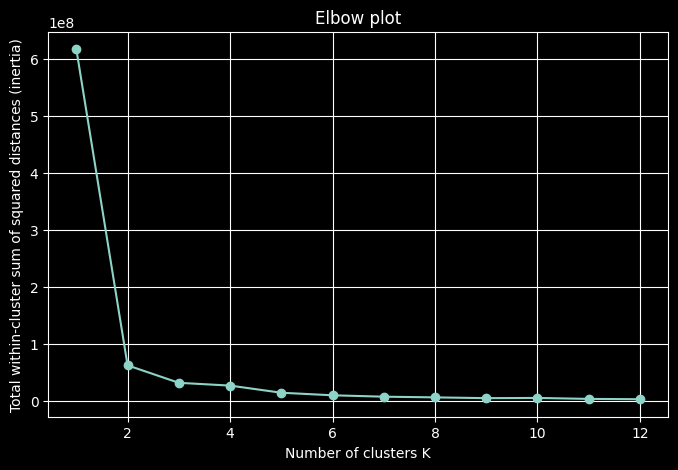

In [41]:
#1 K-Means colour segmentation
img = LoadImage('4_coins.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = range(1,13)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
inertia = []


for k in k_means:
    compactness, labels, centers = cv2.kmeans(
        img,
        k,
        None,
        criteria,
        1,
        cv2.KMEANS_PP_CENTERS
    )
    inertia.append(compactness)

# Plot elbow
plt.figure(figsize=(8,5))
plt.plot(k_means, inertia, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Total within-cluster sum of squared distances (inertia)")
plt.title("Elbow plot")
plt.grid(True)
plt.show()



In [42]:
K_chosen = 4
compactness, labels, centers = cv2.kmeans(
    img,
    K_chosen,
    None,
    criteria,
    10,
    cv2.KMEANS_PP_CENTERS
)

# Centers are Lab colors; convert to RGB for interpretation
centers_rgb = cv2.cvtColor(centers.reshape(-1,1,3).astype(np.uint8), cv2.COLOR_LAB2RGB).reshape(-1,3)
print("Cluster centroids (RGB):")
for i, c in enumerate(centers_rgb):
    print(f"Cluster {i}: {c}")

Cluster centroids (RGB):
Cluster 0: [104  93  78]
Cluster 1: [179 167 149]
Cluster 2: [2 2 2]
Cluster 3: [224 224 222]


K = 4 is a reasonable choice for this image because adding more clusters mostly produces redundant colors, providing little extra information.

Questions
1. Why can two runs of k-means on the same data give different results? What initialisation strategies reduce this variability (you do not need to implement them)?
    - Because it start from a random center, it can therfore be stuck in a local minima, rerun the k-means multiple times and then choose the centers with the lowest total within-cluster variance (inertia)
2. For the same K, did RGB or CIELAB space produce more visually meaningful segments? Explain in terms of how distances are computed in each space.
    - Not sure, i tried different pictures, but most of them looked the same, with minor differences.
    - RGB: Distances are computed as Euclidean distances between Red, Green, and Blue coordinates. The flaw is that numerical distance does not scale linearly with human perception. For example, a small mathematical change in Green appears much larger to a human than the same change in Blue. K-means may therefore group colors that look distinct or split colors that look the same
    - CIELAB: While distances are also Euclidean, the space is specifically designed so that a fixed numerical distance represents the same perceived difference to the human eye across the entire spectrum. Because K-means relies entirely on distance to group pixels, CIELAB ensures that the clusters match human visual logic
3. The elbow plot often does not have a sharp elbow. What does a smooth elbow indicate about the colour distribution in the image?
    - The smooth elbow indicates the iage lasks distinct, well-seperated colour clusters.
    - This could be smooth colour transitions and shadows,
    - It could be significant overlap in the colour distribution, increasing k would therefore not segment improve the segmentation.